In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os
import matplotlib.ticker as ticker
from adjustText import adjust_text
import copy
import statistics
import pandas as pd
#%matplotlib notebook

In [2]:
file_path = "C:\\Users\\zyx\\Desktop\\data\\CO_and_HCO\\source.vsys.dat"
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df = pd.read_csv(
    file_path,
    sep='\s+',          # 按空格/制表符分隔
    comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

print(df)   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查

   source, field,        ra,       dec,       Vsys,  Vsys_sigma
0     Ll01   Ll01  81.505174 -67.503328  287.328125    0.983483
1     Ll02   Ll02  73.534500 -66.775389  274.113342    1.343082
2     Ll03   Ll03  84.478441 -69.576586  265.006836    0.913653
3     Ll04   Ll04  75.983875 -67.344111  269.604950    2.035654
4   Ll04_2   Ll04  75.982767 -67.345826  268.652863    1.179893
..     ...    ...        ...        ...         ...         ...
66     S07    S07  13.514352 -73.327366  163.216629    1.475220
67     S08    S08  12.257295 -73.186037  146.751221    1.218433
68     S09    S09  11.235079 -73.169770  132.257156    2.265169
69     S10    S10  16.280342 -71.995208  189.761490    1.967455
70   S10_2    S10  16.274230 -71.995216  190.884918    1.150420

[71 rows x 6 columns]


In [3]:
sou=df["source,"].tolist()
V=df["Vsys,"].tolist()
print(sou)
print(V)
print(type(sou))
print(type(V))

['Ll01', 'Ll02', 'Ll03', 'Ll04', 'Ll04_2', 'Ll05', 'Ll06', 'Ll06_2', 'Ll06_3', 'Ll07', 'Ll07_2', 'Ll08', 'Ll09', 'Ll09_2', 'Ll09_3', 'Ll09_4', 'Ll09_5', 'Ll10', 'Ll10_2', 'Lm01', 'Lm02', 'Lm02_2', 'Lm02_3', 'Lm03', 'Lm04', 'Lm04_2', 'Lm04_3', 'Lm05', 'Lm05_2', 'Lm05_3', 'Lm06', 'Lm06_2', 'Lm06_3', 'Lm07', 'Lm07_2', 'Lm07_3', 'Lm08', 'Lm09', 'Lm10', 'Lh01', 'Lh01_2', 'Lh01_3', 'Lh02', 'Lh02_2', 'Lh02_3', 'Lh03', 'Lh04', 'Lh05', 'Lh05_2', 'Lh05_3', 'Lh05_4', 'Lh06', 'Lh07', 'Lh08', 'Lh08_2', 'Lh08_3', 'Lh08_4', 'Lh09', 'Lh10', 'S01', 'S01_2', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S10_2']
[287.328125, 274.1133423, 265.0068359, 269.60495, 268.6528625, 274.9273682, 231.8370972, 232.4548035, 235.1858368, 267.088623, 266.247467, 235.3066406, 283.1570435, 282.2198181, 285.8900146, 279.8934326, 281.043335, 249.9293213, 249.9293213, 276.4645691, 230.7684784, 230.9107971, 229.9667053, 296.7356262, 283.2704773, 282.0755615, 284.4465637, 236.2545319, 237.4716644, 233.84242

In [4]:
def open_file():
    path='C:\\Users\\zyx\\Desktop\\data\\spw1'  #设置存储路径
    files= os.listdir(path) #得到文件夹下的所有文件名称
    name_list=source_name(files) # 得到每个源的名字
    data=[]  # 建立空列表储存数据
    data_i=0 # 记录是第几个文件

    for file in files:  #按照顺序在 files 里面进行每一个文件的 数据名称 循环读取
        position = path+"\\"+file   # 打开第一个文件
        data.append([])
        with open(position, 'r') as f:
            line_num=0
            for line in f:
                if line_num>0:
                    data[data_i].append(line.strip().split())
                line_num+=1
        data_i+=1
    return data,name_list

In [5]:
def source_name(name):
    name_list=[]
    for i in range(len(name)):
        part=name[i].split(".")
        name_list.append(part[1])
    return name_list

In [6]:
def data_to_xy(data):   # 输入某一个文件的数据，转换成xy
    data_x=[]
    data_y=[]
    for i in range(len(data)):
        data_x.append(float(data[i][0]))
        data_y.append(float(data[i][1]))
    return data_x,data_y

In [7]:
def paint(x,y):    # 把光谱画出来
    plt.plot(x,y)
    plt.xlabel("frequency (GHz)")
    plt.ylabel("flux (Jy/beam)")
    #plt.autoscale(enable=True, axis='y', tight=True)
    plt.ticklabel_format(useOffset=False, style='plain')
    plt.show()

In [8]:
def noise_sigma(raw_data,a):
    noise=raw_data[a:a+200]    #宽度为0.2Hz的噪声区间
    noise_x,noise_y=data_to_xy(noise)
    #paint(noise_x,noise_y)
    return noise_y

In [9]:
data,name_list=open_file()

indices = [i for i, name in enumerate(name_list) if name == 'Ll02']
for i in sorted(indices, reverse=True):
    del data[i]
    del name_list[i]  # 如果同时需要删除名字列表中的元素
    
indices = [i for i, name in enumerate(name_list) if name == 'Ll04']
for i in sorted(indices, reverse=True):
    del data[i]
    del name_list[i]  # 如果同时需要删除名字列表中的元素
    
print(len(data))
print(len(name_list))
# print(name_list)

190
190


删掉两个源后，注意要修改视向速度

In [10]:
# 归一化（用HCO+的数据归一化）
def guiyihua(list5,flux_HCO):
    list6=[]
    for i in range(len(list5)):
        list6.append(list5[i]/flux_HCO)
        
    return list6

In [11]:
def find_peak2(x,y):
    m=max(y)
    index_m=y.index(m)
    return m,index_m

In [12]:
# 找到每个源的视向速度
def Vsys(name,source,V):
    V_rest_source=[]
    for i in range(len(name)):
        for j in range (len(source)):
            if name[i]==source[j]:
                V_rest_source.append(V[j])
                break
    return V_rest_source

In [13]:
# 找到每个源的HCO+的流量
def guiyi_HCO(name,source,flux):
    F=[]
    for i in range(len(name)):
        for j in range(len(source)):
            if name[i]==source[j]:
                F.append(flux[j])
                break
    return F

In [14]:
# 视向速度
V_rest_source=Vsys(name_list,sou,V)
# print(V_rest_source)
print(len(V_rest_source))
print(len(data))

190
190


In [15]:
# 插值法对齐频率
import numpy as np
from scipy.interpolate import interp1d

def align_spectra_to_grid(spectra, f_start=None, f_end=None, df=None, kind='linear'):
    """
    将多个光谱对齐到统一的频率网格。
    
    参数：
        spectra (list of dict): 每个字典包含'f'和'flux'数组。
        f_start (float): 统一频率范围的起始值。若为None，自动计算。
        f_end (float): 统一频率范围的结束值。若为None，自动计算。
        df (float): 频率步长。若为None，取所有光谱的最小步长。
        kind (str): 插值方法（'linear', 'cubic', 'nearest'）。
    
    返回：
        f_new (np.array): 统一频率网格。
        aligned_flux (np.array): 对齐后的流量矩阵（光谱数 × 频率点数）。
    """
    # 自动确定频率范围和步长
    if f_start is None or f_end is None:
        all_f = np.concatenate([spec['f'] for spec in spectra])
        f_start = all_f.min() if f_start is None else f_start
        f_end = all_f.max() if f_end is None else f_end
    
    if df is None:
        df_list = [np.diff(spec['f']).min() for spec in spectra]
        df = min(df_list)
    
    # 生成统一频率网格
    f_new = np.arange(f_start, f_end + df, df)
    
    # 插值每个光谱
    aligned_flux = []
    for spec in spectra:
        f_orig = spec['f']
        flux_orig = spec['flux']
        # 创建插值函数（超出范围填充NaN）
        interp_func = interp1d(f_orig, flux_orig, kind=kind, bounds_error=False, fill_value=0)
        flux_new = interp_func(f_new)
        aligned_flux.append(flux_new)
    
    return f_new, np.array(aligned_flux)
        

In [16]:
# lll=[[] for _ in range(40)]
# print(lll)
# aaa=[1,2,3]
# bbb=[4,5,6]
# lll[0].append(aaa)
# lll[0].append(bbb)
# print(lll)
# lll[0]=np.concatenate(lll[0]).tolist()
# print(lll)

In [17]:
# 读取HCO+的最大流量信息
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_flux = pd.read_csv(
    "data_with_HCO_flux.txt",
    sep='\s+',          # 按空格/制表符分隔
    #comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

name_HCO=df_flux.iloc[:, 0].tolist()   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查
flux_HCO=df_flux.iloc[:, 1].tolist()

print(flux_HCO)
print(len(flux_HCO))

[0.236722291, 0.332697213, 0.594777167, 0.284221739, 0.50144136, 0.309614241, 0.822760761, 0.342617989, 0.567353308, 0.645932913, 0.151109248, 0.103599511, 0.177517712, 0.0613674298, 0.0974844024, 0.158679515, 0.147837862, 0.353915006, 0.0995358974, 0.163344994, 0.0738406479, 0.183654696, 0.104190871, 0.201626703, 0.402454019, 0.263523281, 0.24253118, 0.44099158, 0.0751578659, 0.028581392, 0.152063936, 0.0628216565, 0.174288481, 0.112904117, 0.155170918, 0.0690230802, 0.206649378, 0.264712214]
38


In [18]:
# HCO+最大流量
F=guiyi_HCO(name_list,name_HCO,flux_HCO)
# print(F)
print(len(F))

190


统一频率网格长度: 2107
对齐后的流量矩阵形状: (38, 2107)
统一频率网格长度: 2107
对齐后的流量矩阵形状: (38, 2107)
统一频率网格长度: 4028
对齐后的流量矩阵形状: (38, 4028)
统一频率网格长度: 4042
对齐后的流量矩阵形状: (38, 4042)
统一频率网格长度: 4044
对齐后的流量矩阵形状: (38, 4044)


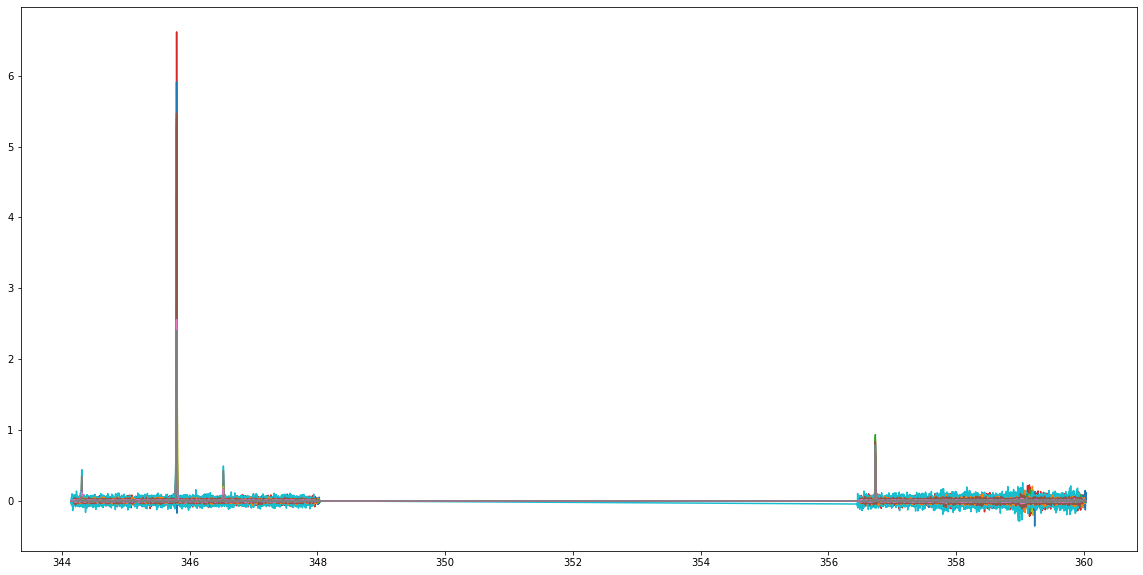

['Lh01', 'Lh02', 'Lh03', 'Lh04', 'Lh05', 'Lh06', 'Lh07', 'Lh08', 'Lh09', 'Lh10', 'Ll01', 'Ll03', 'Ll05', 'Ll06', 'Ll07', 'Ll08', 'Ll09', 'Ll10', 'Lm01', 'Lm02', 'Lm03', 'Lm04', 'Lm05', 'Lm06', 'Lm07', 'Lm08', 'Lm09', 'Lm10', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']


In [19]:
# 删掉识别不出的线和太密集的线
# 对齐速度
c=299792458

plt.figure(figsize=(20,10))
count=38
data_flux=[[] for _ in range(count)]  # 最后用来合并不同通道的列表
data_x=[[] for _ in range(count)]
data_name=[]
for k in range(5):
    f=[]  # 用来组合成字典的列表
    flux=[]
    
    for i in range(count):   #len(data)
        list_x=[]
        list_y=[]
        delta=[]
        
        if k==0:   # 记录源的名字
            data_name.append(name_list[i*5])
            
        
        raw_x,raw_y=data_to_xy(data[i*5+k])   # 一个spw文件的数据
        for j in range(len(raw_x)):    
            list_x.append(raw_x[j]/(1-(V_rest_source[i*5+k]*1000/c)))  # 把视向速度扣掉
            list_y.append(raw_y[j]/F[i*5+k])                   # 用HCO+的流量归一化
        #plt.plot(list_x,list_y)

        f.append(list_x)
        flux.append(list_y)
    #plt.show()

    spectra = [
        {"f": f, "flux": flux}
        for f,flux in zip(f, flux)
    ]

    f_new, aligned_flux = align_spectra_to_grid(spectra, kind='linear')

    # 输出结果形状
    print("统一频率网格长度:", len(f_new))
    print("对齐后的流量矩阵形状:", aligned_flux.shape)

    f_new=list(f_new)
    aligned_flux=list(aligned_flux)

    for m in range(len(aligned_flux)):
        aligned_flux[m]=list(aligned_flux[m])

    for j in range(count):
        data_x[j].append((f_new))
        data_flux[j].append(aligned_flux[j])

for n in range(count):
    data_x[n]=np.concatenate(data_x[n]).tolist()
    data_flux[n]=np.concatenate(data_flux[n]).tolist()



for i in range(count):
#     plt.plot(f_new, aligned_flux[i])
    plt.plot(data_x[i],data_flux[i])
#     plt.title(name_list[i])
#     print(len(data_flux[i]))
plt.show()
print(data_name)

In [20]:
# 读取每个源的光度
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_L = pd.read_csv(
    "C:\\Users\\zyx\\Desktop\\data\\name_L.txt",
    sep='\s+',          # 按空格/制表符分隔
    #comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

print(df_L.iloc[:, 0].tolist())   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查

name_=df_L.iloc[:, 0].tolist()
name_L=df_L.iloc[:, 1].tolist()
print(name_[0][0:4])

['Ll01', 'Ll02', 'Ll03', 'Ll04', 'Ll05', 'Ll06', 'Ll07', 'Ll08', 'Ll09', 'Ll10', 'Lm01', 'Lm02', 'Lm03', 'Lm04', 'Lm05', 'Lm06', 'Lm07', 'Lm08', 'Lm09', 'Lm10', 'Lh01', 'Lh02', 'Lh03', 'Lh04', 'Lh05', 'Lh06', 'Lh07', 'Lh08', 'Lh09', 'Lh10', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
Ll01


In [21]:
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE,MDS, Isomap,LocallyLinearEmbedding,SpectralEmbedding
from sklearn.decomposition import PCA


In [22]:
print(len(data_flux))

38


In [23]:
spec=SpectralEmbedding(n_components=3)
digits_spec=spec.fit_transform(data_flux)

D:\conda\lib\site-packages\sklearn\manifold\_spectral_embedding.py:260: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


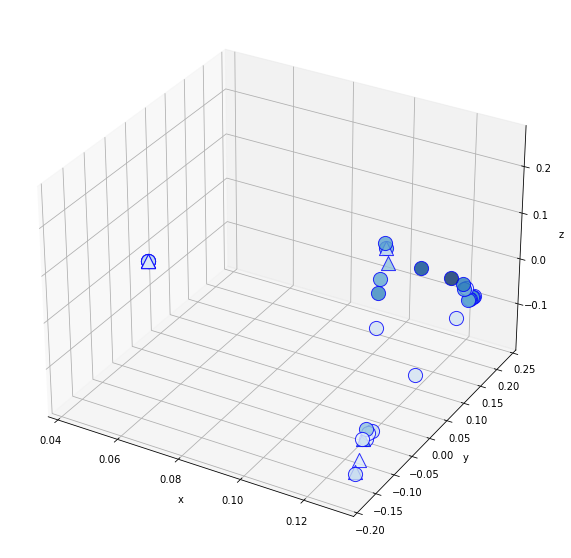

In [24]:
# 画图
# SpectralEmbedding
plt.figure(figsize=(10,10))


# 颜色设置
cmap1=plt.cm.Blues
cmap2=plt.cm.Oranges
cmap3=plt.cm.Purples
cmap4=plt.cm.Greens

ax1 = plt.axes(projection='3d')

# digits_str = name_list[0][2:4]
# print(digits_str)
# print(int(digits_str))

for i in range(len(digits_spec)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax1.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax1.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
        continue
        
    elif data_name[i][0]=="S":
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax1.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax1.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
        continue

ax1.set_ylim([-0.2, 0.25])
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_spec[:, 0], digits_spec[:, 1], data_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend(loc="right")
#plt.savefig('./picture/SpectralEmbedding(Blues)(38).png')
plt.show()

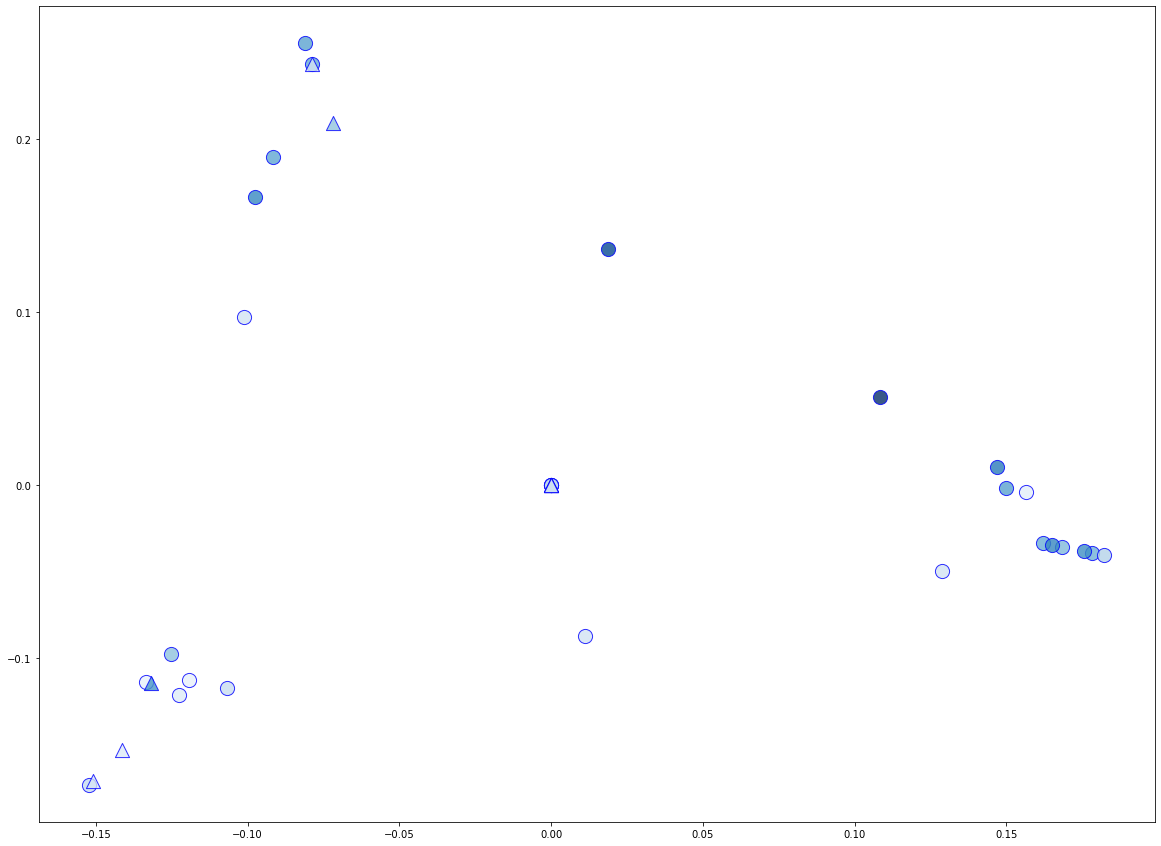

In [25]:
# 画图
# SpectralEmbedding
plt.figure(figsize=(20,15))


# 颜色设置
cmap1=plt.cm.Blues
cmap2=plt.cm.Oranges
cmap3=plt.cm.Purples
cmap4=plt.cm.Greens


# digits_str = name_list[0][2:4]
# print(digits_str)
# print(int(digits_str))

for i in range(len(digits_spec)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_spec[i, 1], digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_spec[i, 1], digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
        continue
        
    elif data_name[i][0]=="S":
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_spec[i, 1], digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_spec[i, 1], digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
        continue


# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_spec[:, 0], digits_spec[:, 1], data_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend(loc="right")
#plt.savefig('./picture/SpectralEmbedding(Blues)(38).png')
plt.show()

In [31]:
# PCA
data_flux=np.array(data_flux)
print(data_flux.shape)
model = PCA(5)  # project from  to 2 dimensions
model.fit(data_flux)
digits_pca = model.transform(data_flux)

(38, 16328)


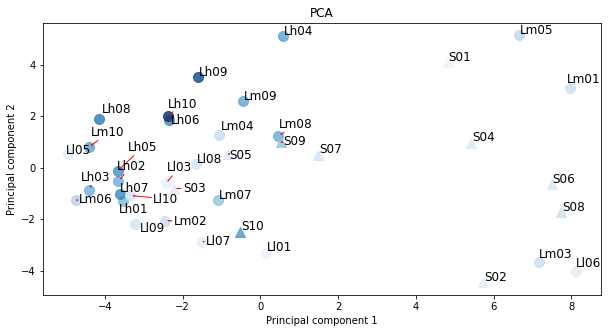

In [27]:
# PCA画图
plt.figure(figsize=(10,5))
for i in range(len(digits_pca)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_pca[i, 0], digits_pca[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8)
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_pca[i, 0], digits_pca[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8)
                    break
        continue
        
    elif data_name[i][0]=="S":
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_pca[i, 0], digits_pca[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8,marker="^")
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_pca[i, 0], digits_pca[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8,marker="^")
                    break
        continue
    
new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_pca[:, 0], digits_pca[:, 1], data_name)]
adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend()
plt.title("PCA")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
#plt.savefig('./picture/pca(Blues)(38).png')
plt.show()



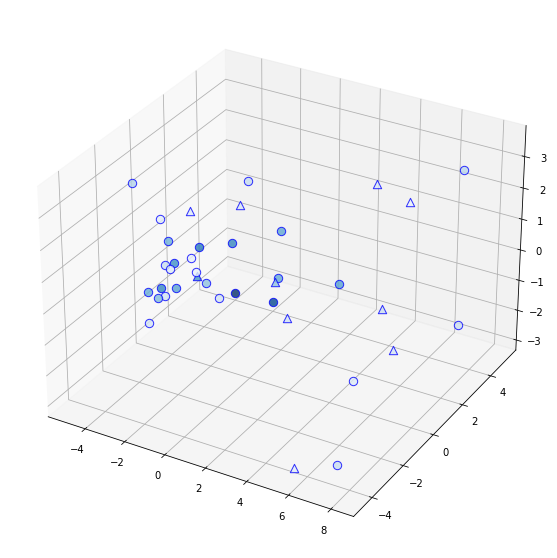

In [28]:
plt.figure(figsize=(10,10))
ax2 = plt.axes(projection='3d')
for i in range(len(digits_pca)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax2.scatter3D(digits_pca[i, 0], digits_pca[i, 1],digits_pca[i, 2], s=70,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax2.scatter3D(digits_pca[i, 0], digits_pca[i, 1],digits_pca[i, 2],  s=70,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
        continue
        
    elif data_name[i][0]=="S":
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax2.scatter3D(digits_pca[i, 0], digits_pca[i, 1], digits_pca[i, 2], s=70,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax2.scatter3D(digits_pca[i, 0], digits_pca[i, 1],digits_pca[i, 2],  s=70,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
        continue
    
# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_pca[:, 0], digits_pca[:, 1], data_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend()
# plt.title("PCA")
# plt.xlabel("Principal component 1")
# plt.ylabel("Principal component 2")
#plt.savefig('./picture/pca(Blues)(38).png')
plt.show()

In [41]:
# 5. 输出PCA的主成分和解释方差
print("主成分（特征向量）：\n", model.components_)
print("解释方差（每个主成分的贡献）：", model.explained_variance_ratio_)
component=model.components_
ratio=model.explained_variance_ratio_
mean=model.mean_
print(mean)

主成分（特征向量）：
 [[-0.00028784 -0.00043015 -0.00015825 ...  0.00139702  0.00132046
   0.        ]
 [ 0.00068254  0.00102     0.00037524 ... -0.00217977 -0.00206031
   0.        ]
 [ 0.00097383  0.00145532  0.00053539 ... -0.00376409 -0.0035578
   0.        ]
 [ 0.00031466  0.00047024  0.00017299 ... -0.00315096 -0.00297827
  -0.        ]
 [-0.00194872 -0.00291223 -0.00107136 ...  0.00155839  0.00147299
  -0.        ]]
解释方差（每个主成分的贡献）： [0.52960721 0.17393453 0.07865388 0.04648874 0.03802877]
[-0.00085376 -0.00127589 -0.00046938 ...  0.00330676  0.00312553
  0.        ]


重建均方误差: 0.0003


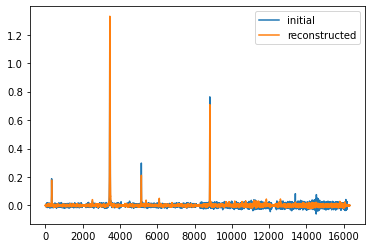

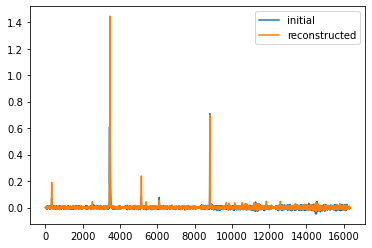

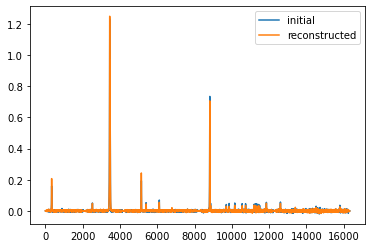

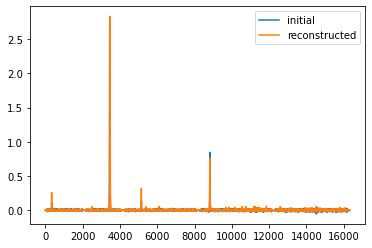

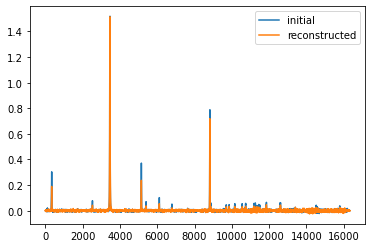

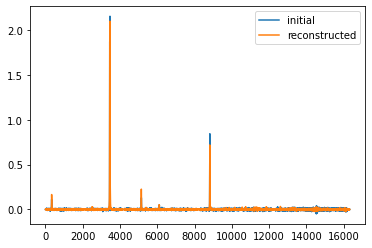

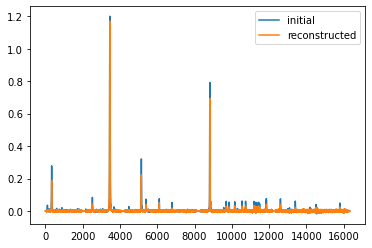

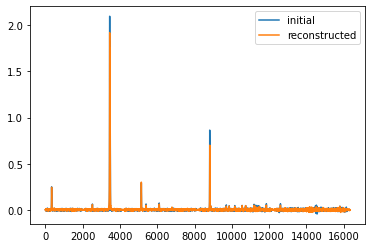

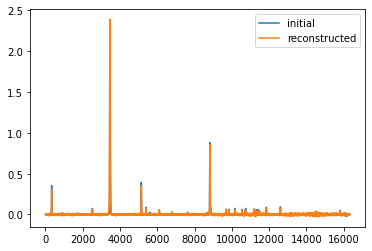

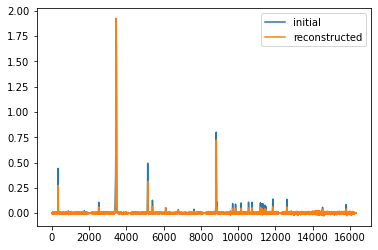

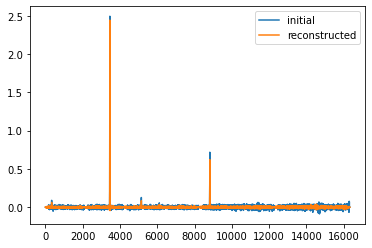

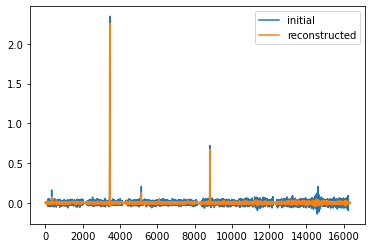

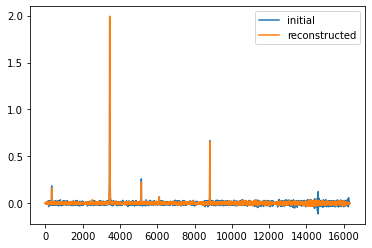

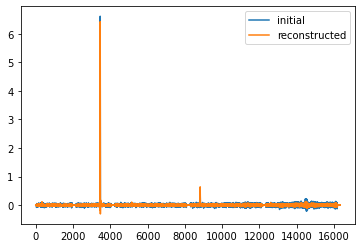

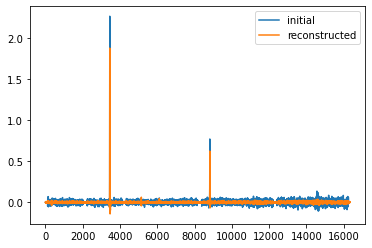

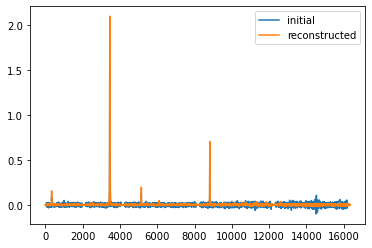

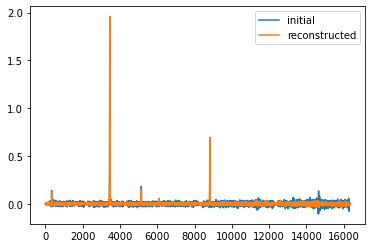

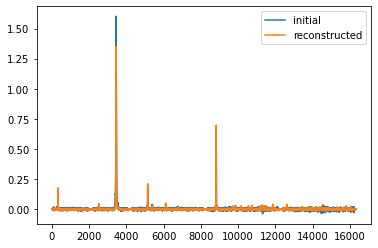

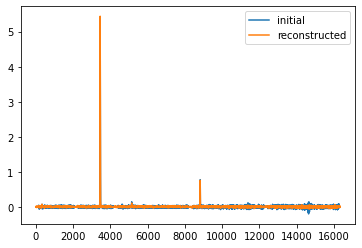

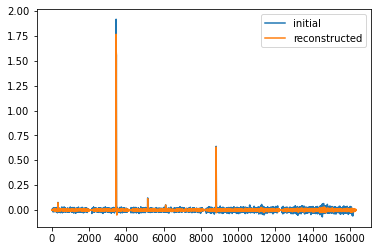

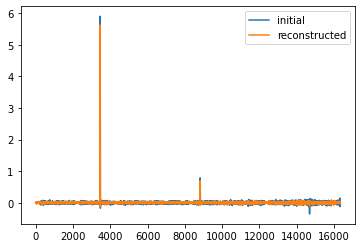

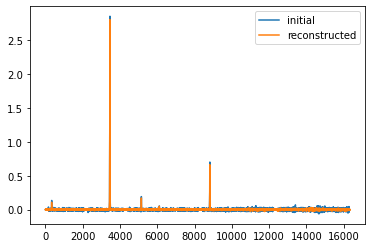

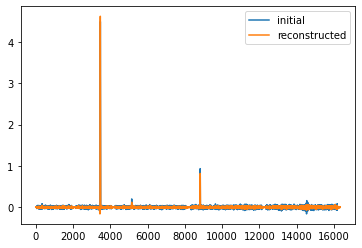

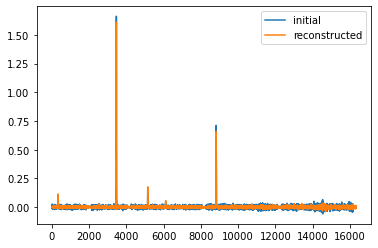

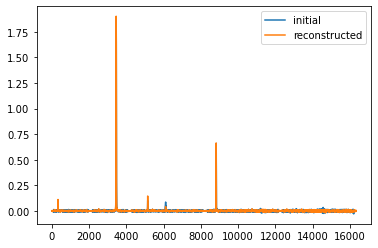

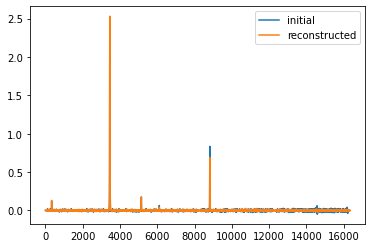

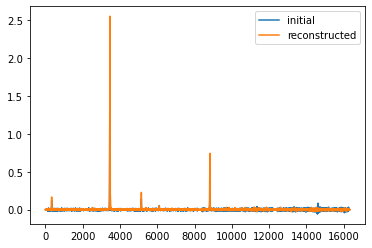

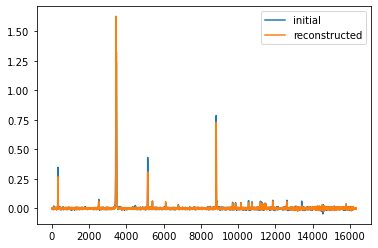

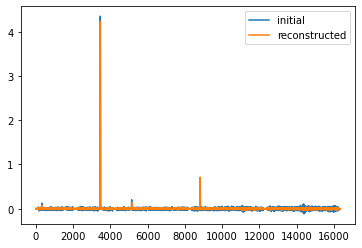

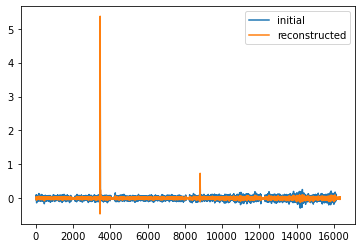

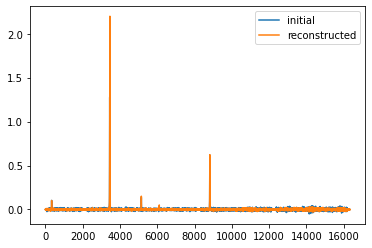

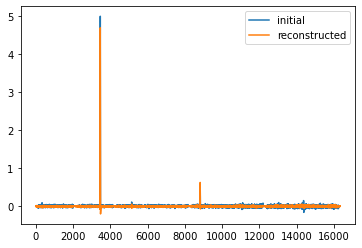

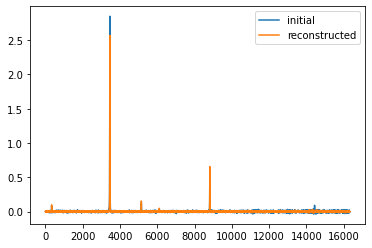

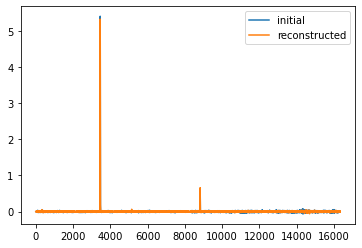

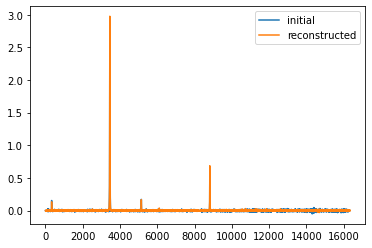

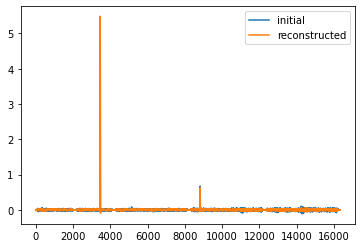

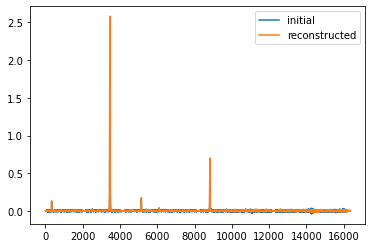

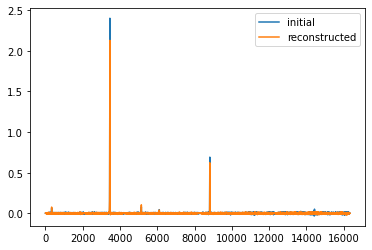

In [47]:
# 尝试合成大谱线
# difference1=[]
# difference2=[]
# difference3=[]
# for i in range(len(digits_pca)):  # 第i根谱线的预测
#     predic1=digits_pca[i,0]*ratio[0]*component[0]+digits_pca[i,1]*ratio[1]*component[1]+digits_pca[i,2]*ratio[2]*component[2]
#     predic2=(digits_pca[i,0]*ratio[0]*component[0]+digits_pca[i,1]*ratio[1]*component[1]+digits_pca[i,2]*ratio[2]*component[2]
#              +digits_pca[i,3]*ratio[3]*component[3])
#     predic3=(digits_pca[i,0]*ratio[0]*component[0]+digits_pca[i,1]*ratio[1]*component[1]+digits_pca[i,2]*ratio[2]*component[2]
#              +digits_pca[i,3]*ratio[3]*component[3]+digits_pca[i,4]*ratio[4]*component[4])
#     sum1=0
#     sum2=0
#     sum3=0
    
#     for j in range(len(predic1)):   #第i根谱线长为j，把所有点的差值求出来
#         sum1+=abs(predic1[j]-data_flux[i][j])
#         sum2+=abs(predic2[j]-data_flux[i][j])
#         sum3+=abs(predic3[j]-data_flux[i][j])
#     difference1.append(sum1)
#     difference2.append(sum2)
#     difference3.append(sum3)
#     print(sum1/sum(data_flux[i]))
# plt.plot(difference1,marker=".",color="blue",label="3")
# plt.plot(difference2,marker=".",color="green",label="4")
# plt.plot(difference3,marker=".",color="orange",label="5")
# plt.show()

digits_reconstructed = digits_pca @ component + mean
mse = np.mean((data_flux - digits_reconstructed) ** 2)
print(f"重建均方误差: {mse:.4f}")
for i in range(len(digits_pca)):
    plt.plot(data_flux[i],label="initial")
    plt.plot(digits_reconstructed[i],label="reconstructed")
    plt.legend()
    plt.show()

In [23]:
# 求平均谱线
def mean_spec(list7):
    mean=[]
    for i in range(len(list7[0])):  # 数据长度
        mean_data=0
        for j in range(len(list7)):   # 有几组数据
            mean_data+=list7[j][i]
        mean.append(mean_data/len(list7))
    return mean

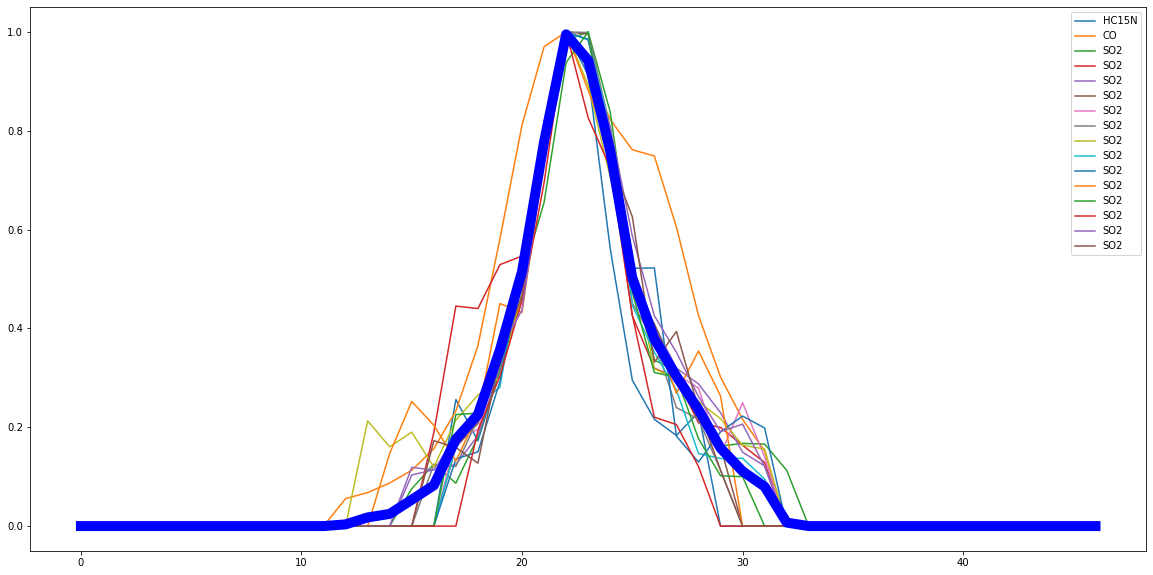

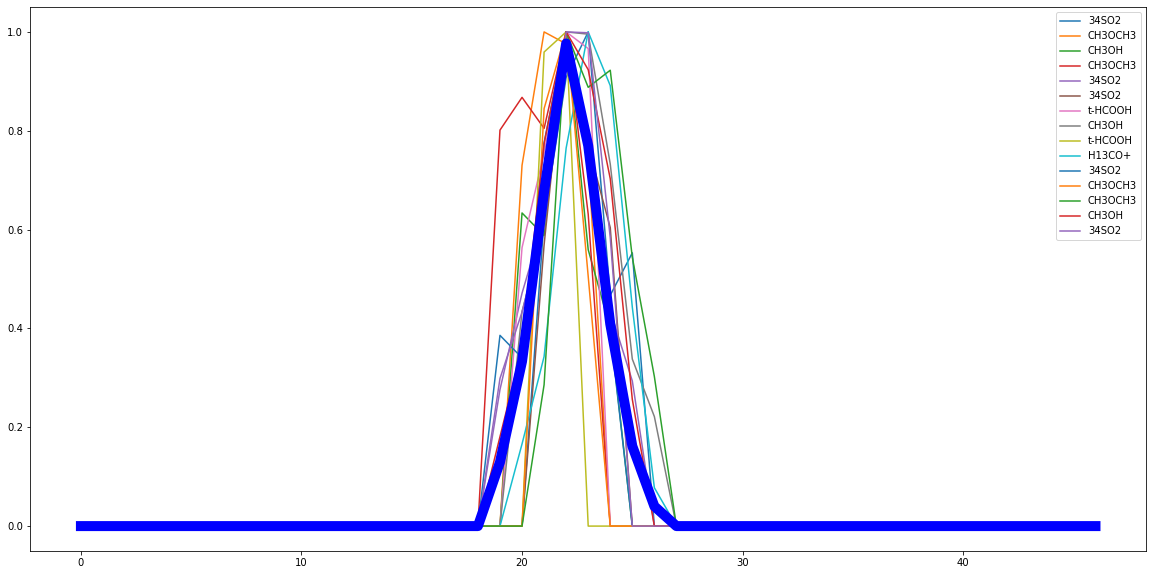

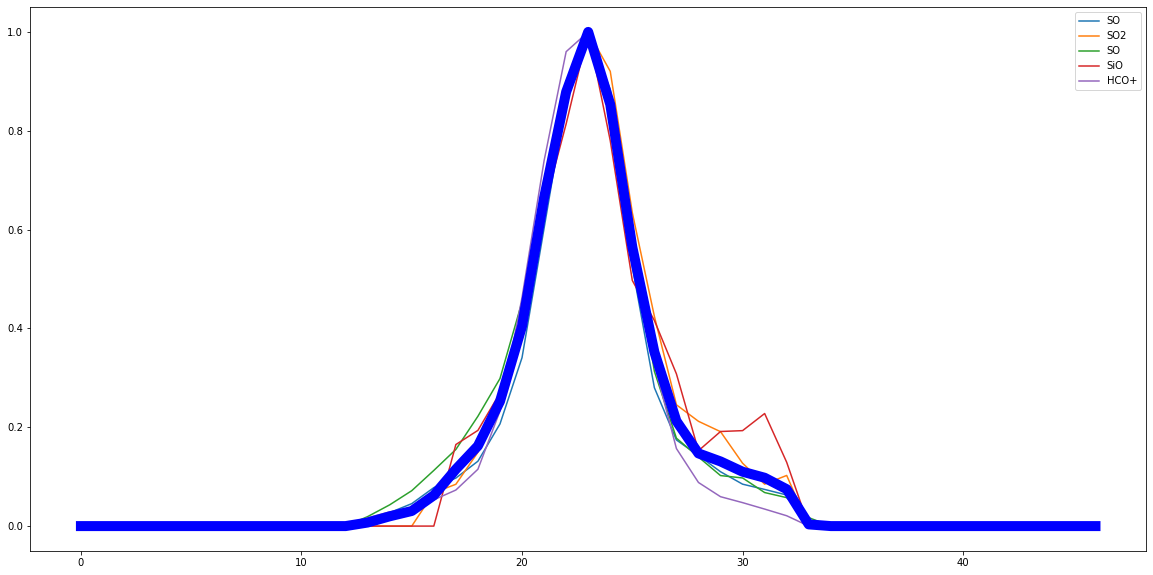

In [24]:
#print(digits_spec)
cate1=[]
name1=[]
mean1=[]
cate2=[]
name2=[]
mean2=[]
cate3=[]
name3=[]
mean3=[]
for i in range(len(digits_spec)):
    if digits_spec[i,0]>0 and digits_spec[i,1]<0.15:
        cate1.append(data_flux[i])
        name1.append(new_name[i])
        
    elif digits_spec[i,0]<0 and digits_spec[i,1]<0.15:
        cate2.append(data_flux[i])
        name2.append(new_name[i])
    elif digits_spec[i,0]<0.0 and digits_spec[i,1]>0.15:
        cate3.append(data_flux[i])
        name3.append(new_name[i])

# 求平均光谱
mean1=mean_spec(cate1)
mean2=mean_spec(cate2)
mean3=mean_spec(cate3)

# 画图
plt.figure(figsize=(20,10))
for i in range(len(cate1)):  
    plt.plot(cate1[i],label=name1[i])

plt.plot(mean1,linewidth=10,color="b")
#plt.ylim(-0.05,0.1)
plt.legend()
plt.show()

plt.figure(figsize=(20,10))
for i in range(len(cate2)):
    plt.plot(cate2[i],label=name2[i])

plt.plot(mean2,linewidth=10,color="b")
#plt.xlim(25,150)
plt.legend()
plt.show()

plt.figure(figsize=(20,10))
for i in range(len(cate3)):
    plt.plot(cate3[i],label=name3[i])

plt.plot(mean3,linewidth=10,color="b")
#plt.xlim(25,150)
plt.legend()
plt.show()

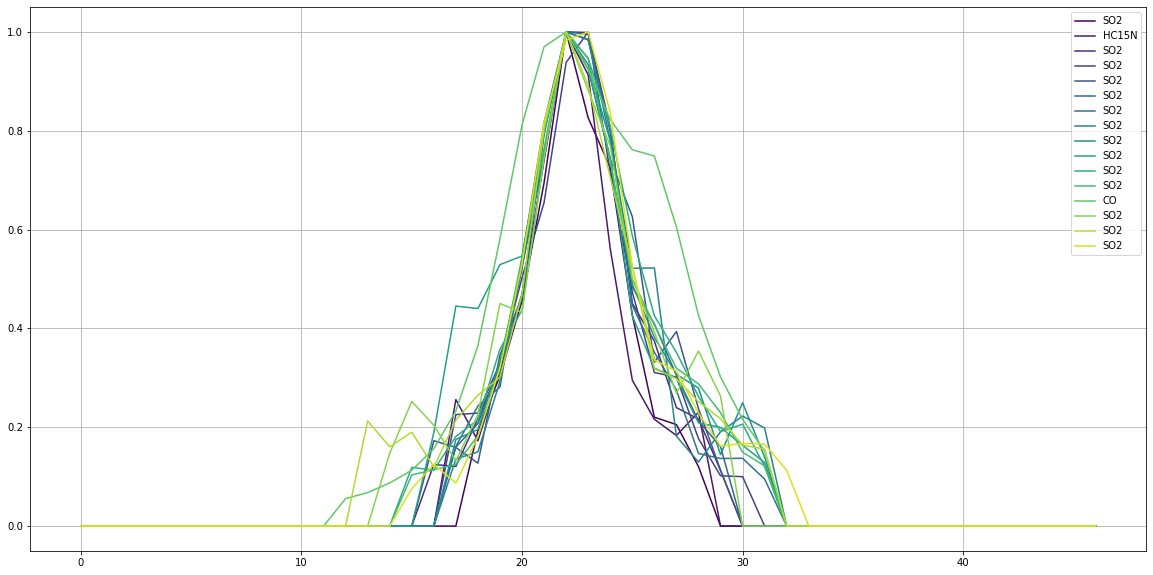

In [25]:
# 把SO2的x增大顺序画出来
sort_x_so2=[]    # 按顺序排列的x值
cate1_x_so2=[]  # x值
digits_so2_x=[]  # 谱线流量
name_so2_x=[]    # 记录谱线的名字

for i in range(len(digits_spec)):
    if digits_spec[i,0]>0 and digits_spec[i,1]<0.15:
        digits_so2_x.append(digits_spec[i,0])
        cate1_x_so2.append(data_flux[i])
        name_so2_x.append(new_name[i])
        
linewidth_x=[]
x_so2=zip(digits_so2_x,cate1_x_so2,name_so2_x)
sorted_x_so2 = sorted(x_so2,key=lambda x:x[0])
result = zip(*sorted_x_so2)
sorted_so2_x, sorted_so2_flux,sorted_so2_name = [list(x) for x in result]

cmap = plt.cm.viridis
plt.figure(figsize=(20,10))

for i in range(len(sorted_so2_flux)):   # 算一下线宽（最底部）
    #print(sorted_so2_x[i])
    a=0
    b=0
    for j in range(len(sorted_so2_flux[i])-1):
        if sorted_so2_flux[i][j]==0 and sorted_so2_flux[i][j+1]>0:
            a=j
        if sorted_so2_flux[i][j]==0 and sorted_so2_flux[i][j-1]>0:
            b=j
    
    #print("线宽：",b-a)
    linewidth_x.append(b-a)
    
    color = cmap(i / len(sorted_so2_flux))
    plt.plot(sorted_so2_flux[i],color=color,label=sorted_so2_name[i])
    #plt.title("x value:{}".format(sorted_so2_x[i]))
    #plt.title("name:{}".format(sorted_so2_name[i]))
    #plt.savefig('./picture/sorted_x-{}.png'.format(i + 1))


plt.legend(loc="upper right")
plt.grid()
plt.show()

#print(linewidth_x)

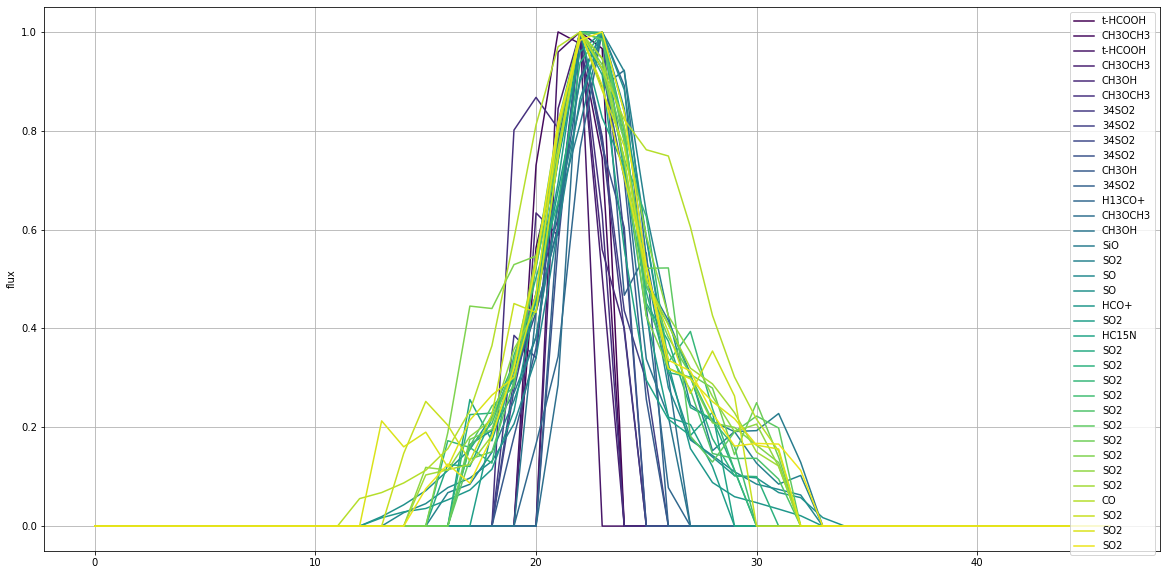

In [26]:
# 把所有谱线按的x增大顺序画出来
sort_x=[]    # 按x顺序排列的下面三个列表的组合
cate1_x=[]  # 谱线流量
digits_x=[]  # 分类结果中该谱线的x值
name_x=[]    # 记录谱线的名字

for i in range(len(digits_spec)):
    digits_x.append(digits_spec[i,0])
    cate1_x.append(data_flux[i])
    name_x.append(new_name[i])
        
linewidth_x_all=[]
x_=zip(digits_x,cate1_x,name_x)
sort_x = sorted(x_,key=lambda x:x[0])
result = zip(*sort_x)
sorted_x, sorted_flux,sorted_name = [list(x) for x in result]

cmap = plt.cm.viridis
plt.figure(figsize=(20,10))

for i in range(len(sorted_flux)):   # 算一下线宽（最底部）
    #print(sorted_so2_x[i])
    a=0
    b=0
    for j in range(len(sorted_flux[i])-1):
        if sorted_flux[i][j]==0 and sorted_flux[i][j+1]>0:
            a=j
        if sorted_flux[i][j]==0 and sorted_flux[i][j-1]>0:
            b=j
    
    #print("线宽：",b-a)
    linewidth_x_all.append(b-a)
    
    color = cmap(i / len(sorted_flux))
    plt.plot(sorted_flux[i],color=color,label=sorted_name[i])
    #plt.title("x value:{}".format(sorted_so2_x[i]))
    #plt.title("name:{}".format(sorted_so2_name[i]))
    #plt.savefig('./picture/sorted_x-{}.png'.format(i + 1))


plt.legend(loc="upper right")
plt.ylabel("flux")
plt.grid()
plt.show()

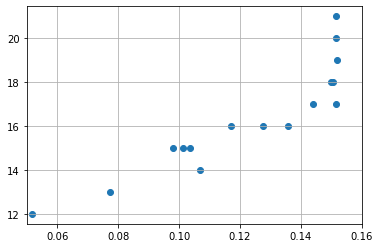

In [27]:
# 画出x值和线宽的散点图
sorted_so2_x = np.array(sorted_so2_x)
linewidth_x = np.array(linewidth_x)
plt.scatter(sorted_so2_x,linewidth_x)
plt.xlim(0.05,0.16)
plt.grid()
plt.show()

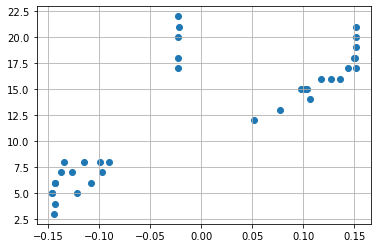

In [28]:
# 画出所有谱线x值和线宽的散点图
sorted_x = np.array(sorted_x)
linewidth_x_all = np.array(linewidth_x_all)
plt.scatter(sorted_x,linewidth_x_all)
#plt.xlim(0.05,0.16)
plt.grid()
plt.show()

In [29]:
# 把SO2的y增大顺序画出来
sort_y_so2=[]
cate1_y_so2=[]
digits_so2_y=[]

for i in range(len(digits_spec)):
    if digits_spec[i,0]>0 and digits_spec[i,1]<0.15:
        digits_so2_y.append(digits_spec[i,1])
        cate1_y_so2.append(data_flux[i])
        
linewidth_y=[]
y_so2=zip(digits_so2_y,cate1_y_so2)
sorted_y_so2 = sorted(y_so2,key=lambda x:x[0])
result = zip(*sorted_y_so2)
sorted_so2_y, sorted_so2_flux = [list(x) for x in result]

for i in range(len(sorted_so2_flux)):   # 算一下线宽（最底部）
    print(sorted_so2_y[i])
    a=0
    b=0
    for j in range(len(sorted_so2_flux[i])-1):
        if sorted_so2_flux[i][j]==0 and sorted_so2_flux[i][j+1]>0:
            a=j
        if sorted_so2_flux[i][j]==0 and sorted_so2_flux[i][j-1]>0:
            b=j
    linewidth_y.append(b-a)
    print("线宽：",b-a)
#     plt.plot(sorted_so2_flux[i])
#     plt.title("y value:{}".format(sorted_so2_y[i]))
#     plt.savefig('./picture/sorted_y-{}.png'.format(i + 1))
#     plt.show()
print(linewidth_y)

-0.10295652931425181
线宽： 19
-0.10250386678181798
线宽： 21
-0.10250386678181794
线宽： 20
-0.10250386678181786
线宽： 17
-0.09926937037413046
线宽： 18
-0.09667348809249963
线宽： 18
-0.07791596838945215
线宽： 17
-0.0522679913437954
线宽： 16
-0.0270401583472192
线宽： 16
0.0005789567123304899
线宽： 16
0.027958887762676618
线宽： 14
0.03684363076079418
线宽： 15
0.03695772879455899
线宽： 15
0.0426882326806361
线宽： 15
0.07710567738732602
线宽： 13
0.11054892432629239
线宽： 12
[19, 21, 20, 17, 18, 18, 17, 16, 16, 16, 14, 15, 15, 15, 13, 12]


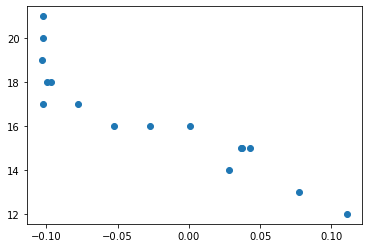

In [30]:
# 画出y值和线宽的散点图
plt.scatter(sorted_so2_y,linewidth_y)

plt.show()

In [31]:
# 计算半高全宽
def calculate_fwhm(x, y, n): # n是取多少高
    # 确保x和y为NumPy数组
    x = np.asarray(x)
    y = np.asarray(y)
    
    # 找到峰值位置
    peak_index = np.argmax(y)
    peak_value = y[peak_index]
    half_max = peak_value*n

    # 处理左侧交点
    i_left = peak_index - 1
    while i_left >= 0 and y[i_left] > half_max:
        i_left -= 1
    
    if i_left < 0:
        raise ValueError("未找到左侧半高交点，请检查数据。")
    if i_left + 1 >= len(y):
        raise ValueError("左侧交点超出范围。")
    
    # 线性插值计算左侧交点x坐标
    dx_left = x[i_left + 1] - x[i_left]
    dy_left = y[i_left + 1] - y[i_left]
    x_left = x[i_left] + (half_max - y[i_left]) * dx_left / dy_left

    # 处理右侧交点
    i_right = peak_index + 1
    while i_right < len(y) and y[i_right] >= half_max:
        i_right += 1
    
    if i_right >= len(y):
        raise ValueError("未找到右侧半高交点，请检查数据。")
    if i_right - 1 < peak_index:
        raise ValueError("右侧交点无效。")
    
    # 线性插值计算右侧交点x坐标
    dx_right = x[i_right] - x[i_right - 1]
    dy_right = y[i_right] - y[i_right - 1]
    x_right = x[i_right - 1] + (half_max - y[i_right - 1]) * dx_right / dy_right
    return x_right - x_left

In [32]:
# 底线宽
def linewidth(y):
    a=0
    b=0
    for i in range(len(y)-1):
        if y[i]==0 and y[i+1]>0:
            a=i
        if y[i]==0 and y[i-1]>0:
            b=i
    
    #print("线宽：",b-a)
    return (b-a)

In [33]:
def simpson_integral(x, y):
    # 检查数据均匀间隔
    h = x[1] - x[0]
    for i in range(1, len(x)):
        if not np.isclose(x[i] - x[i-1], h):
            raise ValueError("数据点必须均匀间隔！")
    
    # 检查偶数个区间（数据点数为奇数）
    n = len(x) - 1  # 区间数
    if n % 2 != 0:
        raise ValueError("区间数需为偶数（数据点数需为奇数）")
    
    # 辛普森公式计算
    integral = y[0] + y[-1]
    for i in range(1, n):
        if i % 2 == 0:
            integral += 2 * y[i]
        else:
            integral += 4 * y[i]
    integral *= h / 3
    return integral

In [34]:
# 面积
def area(x,y):
    a=np.trapz(y, x)
    return a

In [35]:
# 面积比值
def a_ratio(x,y,n):
# 找到对应高度的横坐标
    # 确保x和y为NumPy数组
    x = np.asarray(x)
    y = np.asarray(y)
    
    # 找到峰值位置
    peak_index = np.argmax(y)
    peak_value = y[peak_index]
    half_max = peak_value*n

    # 处理左侧交点
    i_left = peak_index - 1
    while i_left >= 0 and y[i_left] > half_max:
        i_left -= 1
    
    if i_left < 0:
        raise ValueError("未找到左侧半高交点，请检查数据。")
    if i_left + 1 >= len(y):
        raise ValueError("左侧交点超出范围。")
    
    # 线性插值计算左侧交点x坐标
    dx_left = x[i_left + 1] - x[i_left]
    dy_left = y[i_left + 1] - y[i_left]
    x_left = x[i_left] + (half_max - y[i_left]) * dx_left / dy_left

    # 处理右侧交点
    i_right = peak_index + 1
    while i_right < len(y) and y[i_right] >= half_max:
        i_right += 1
    
    if i_right >= len(y):
        raise ValueError("未找到右侧半高交点，请检查数据。")
    if i_right - 1 < peak_index:
        raise ValueError("右侧交点无效。")
    
    # 线性插值计算右侧交点x坐标
    dx_right = x[i_right] - x[i_right - 1]
    dy_right = y[i_right] - y[i_right - 1]
    x_right = x[i_right - 1] + (half_max - y[i_right - 1]) * dx_right / dy_right
    
# 计算面积
    x_left_int=int(x_left)
    x_right_int=int(x_right)
    left=np.arange(0,x_left_int+1)
    right=np.arange(x_right_int+1,x[-1]+1)
    area_left=np.trapz( y[0:x_left_int+1],left)
    area_right=np.trapz(y[x_right_int+1:x[-1]+1],right)
    area_middle=(x_right-x_left)*half_max
    return area_left+area_right

In [36]:
def tr(a):
    a+=1
    return a
aaa=1
print(tr(aaa))
print(aaa)

2
1


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]


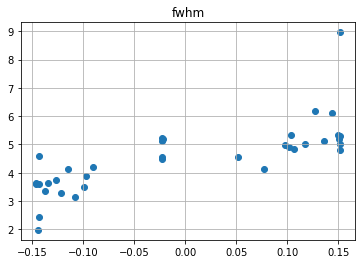

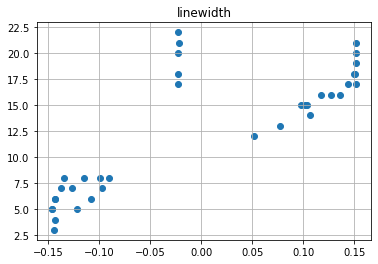

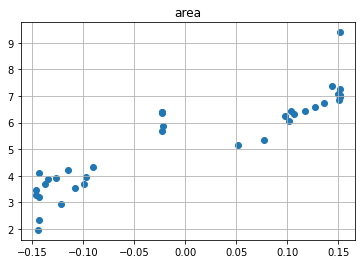

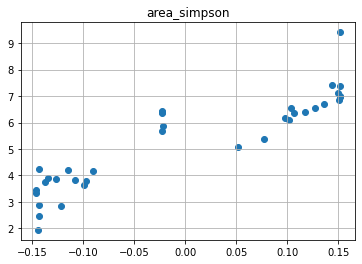

In [37]:
fwhm_full=[]
linewidth_full=[]
area_full=[]
area_full2=[]
flux_x = np.arange(0, len(sorted_flux[1]),1)
print(flux_x)
for i in range(len(sorted_x)):
    fwhm=calculate_fwhm(flux_x,sorted_flux[i],0.5)
    fwhm_full.append(fwhm)
    linewid=linewidth(sorted_flux[i])
    linewidth_full.append(linewid)
    area_full.append(area(flux_x,sorted_flux[i]))
    area2 = simpson_integral(flux_x,sorted_flux[i])
    area_full2.append(area2)

# 画出所有谱线x值和不同属性的散点图
plt.scatter(sorted_x,fwhm_full)
#plt.xlim(0.05,0.16)
plt.title("fwhm")
plt.grid()
plt.show()

plt.scatter(sorted_x,linewidth_full)
#plt.xlim(0.05,0.16)
plt.title("linewidth")
plt.grid()
plt.show()

plt.scatter(sorted_x,area_full)
#plt.xlim(0.05,0.16)
plt.title("area")
plt.grid()
plt.show()

plt.scatter(sorted_x,area_full2)
#plt.xlim(0.05,0.16)
plt.title("area_simpson")
plt.grid()
plt.show()

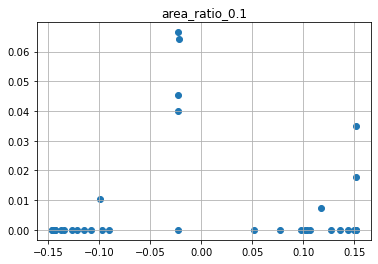

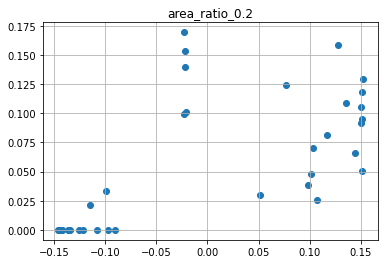

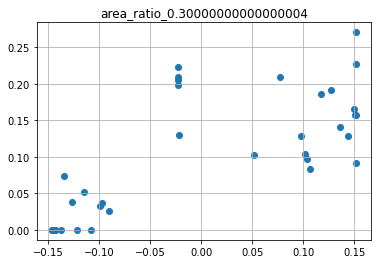

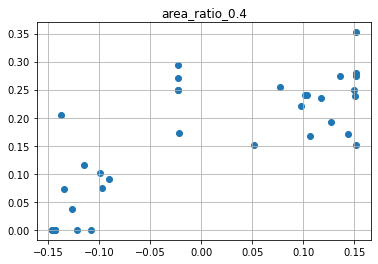

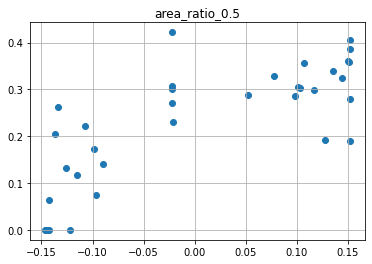

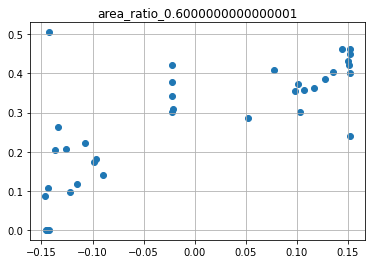

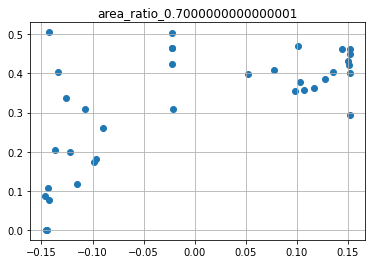

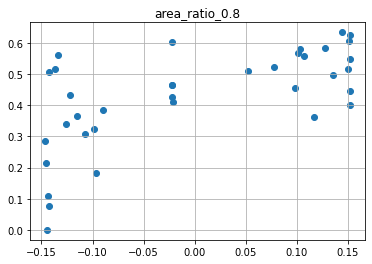

In [38]:

flux_x = np.arange(0, len(sorted_flux[1]),1)
for n in range(1,9):
    area_full=[]
    area_ratio=[]
    for i in range(len(sorted_x)):
        area_full.append(area(flux_x,sorted_flux[i]))
        area_ratio.append(a_ratio(flux_x,sorted_flux[i],n*0.1)/area(flux_x,sorted_flux[i]))
    plt.scatter(sorted_x,area_ratio)
    #plt.xlim(0.05,0.16)
    plt.title("area_ratio_{}".format(n*0.1))
    plt.grid()
    plt.show()

In [39]:
# 均方根
def ruggedness_rms(y):
    dy = np.diff(y)
    return np.sqrt(np.mean(dy**2))

In [40]:
# 信息熵
def ruggedness_entropy(y):
    y_normalized = y / np.sum(y)
    entropy = -np.sum(y_normalized * np.log2(y_normalized + 1e-10))  # 避免log(0)
    return entropy

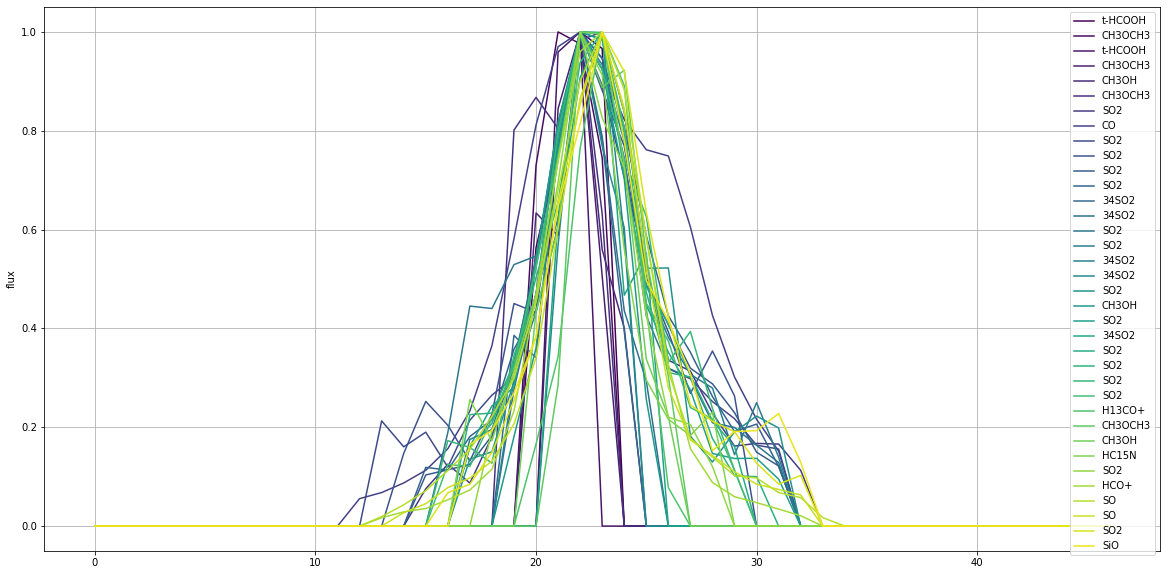

In [41]:
# 把所有谱线按y的增大顺序画出来
sort_y=[]    # 按顺序排列的y值
cate1_y=[]  # x值
digits_y=[]  # 谱线流量
name_y=[]    # 记录谱线的名字

for i in range(len(digits_spec)):
    digits_y.append(digits_spec[i,1])
    cate1_y.append(data_flux[i])
    name_y.append(new_name[i])
        
y_=zip(digits_y,cate1_y,name_y)
sort_y = sorted(y_,key=lambda x:x[0])
result = zip(*sort_y)
sorted_y, sorted_flux_y,sorted_name_y = [list(x) for x in result]

cmap = plt.cm.viridis
plt.figure(figsize=(20,10))

rms_y=[]
entropy_y=[]
linewidth_y=[]
fwhm_y=[]
area_y=[]

for i in range(len(sorted_flux_y)):
    color = cmap(i / len(sorted_flux_y))
    plt.plot(sorted_flux_y[i],color=color,label=sorted_name_y[i])
    rms_y.append(ruggedness_rms(sorted_flux_y[i]))
    entropy_y.append(ruggedness_entropy(sorted_flux_y[i]))
    linewidth_y.append(linewidth(sorted_flux_y[i]))
    fwhm_y.append(calculate_fwhm(flux_x,sorted_flux_y[i],0.5))
    area_y.append(area(flux_x,sorted_flux_y[i]))

plt.legend(loc="upper right")
plt.ylabel("flux")
plt.grid()
plt.show()

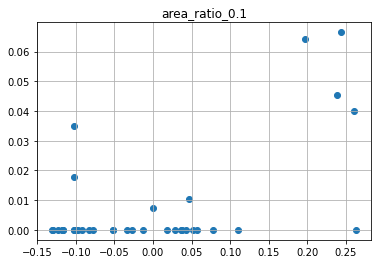

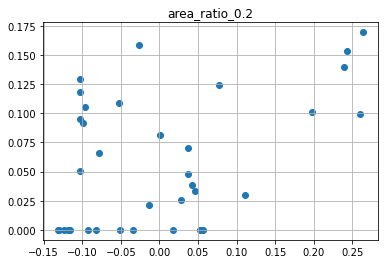

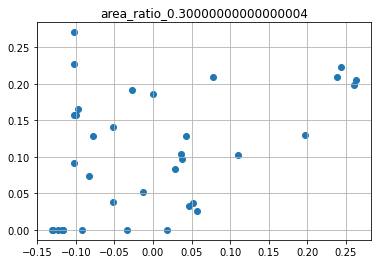

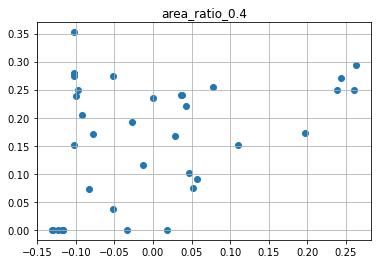

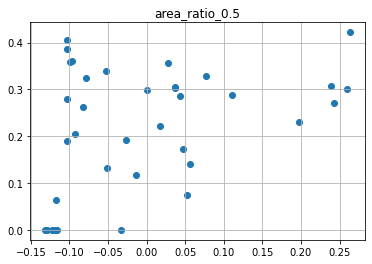

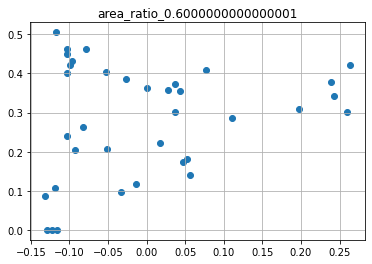

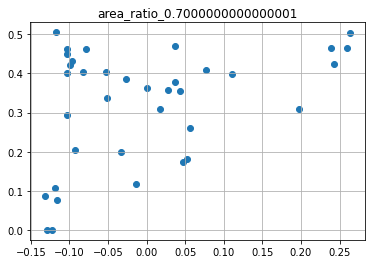

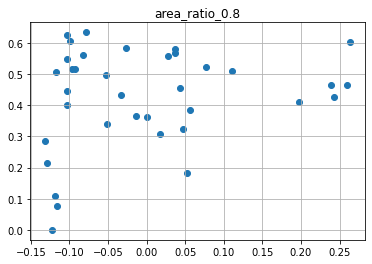

In [42]:
flux_x = np.arange(0, len(sorted_flux_y[1]),1)
for n in range(1,9):
    area_full_y=[]
    area_ratio_y=[]
    for i in range(len(sorted_y)):
        area_full_y.append(area(flux_x,sorted_flux_y[i]))
        area_ratio_y.append(a_ratio(flux_x,sorted_flux_y[i],n*0.1)/area(flux_x,sorted_flux_y[i]))
    plt.scatter(sorted_y,area_ratio_y)
    #plt.xlim(0.05,0.16)
    plt.title("area_ratio_{}".format(n*0.1))
    plt.grid()
    plt.show()

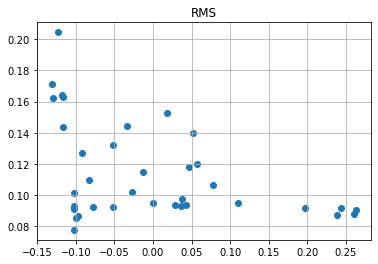

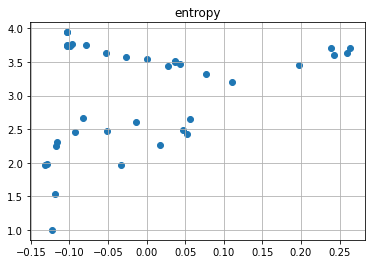

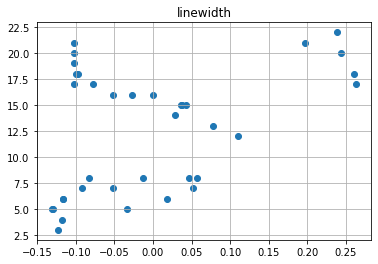

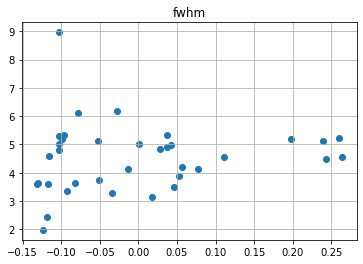

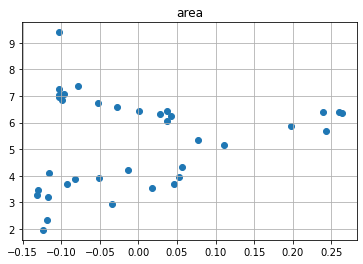

In [43]:
# 画出所有谱线y值和不同属性的散点图
plt.scatter(sorted_y,rms_y)
#plt.xlim(0.05,0.16)
plt.title("RMS")
plt.grid()
plt.show()

plt.scatter(sorted_y,entropy_y)
#plt.xlim(0.05,0.16)
plt.title("entropy")
plt.grid()
plt.show()

plt.scatter(sorted_y,linewidth_y)
#plt.xlim(0.05,0.16)
plt.title("linewidth")
plt.grid()
plt.show()

plt.scatter(sorted_y,fwhm_y)
#plt.xlim(0.05,0.16)
plt.title("fwhm")
plt.grid()
plt.show()

plt.scatter(sorted_y,area_y)
#plt.xlim(0.05,0.16)
plt.title("area")
plt.grid()
plt.show()

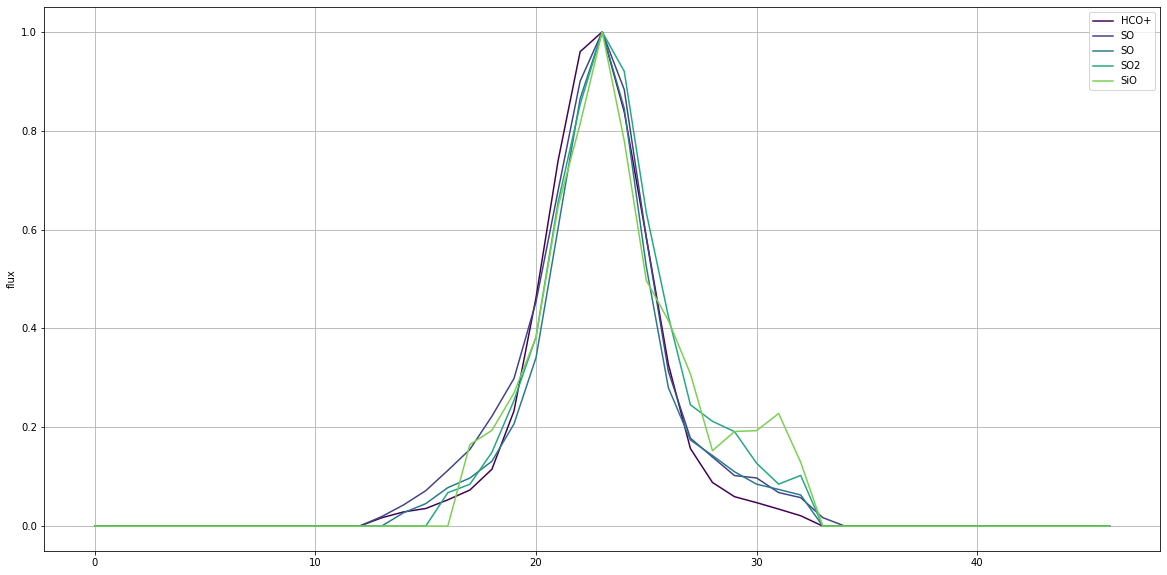

[0.19718835966940468, 0.23868247544660212, 0.24321204828855933, 0.25984216598361326, 0.26316346799936385]


In [44]:
# 把下半部分谱线按y的增大顺序画出来
sort_y_down=[]    # 按顺序排列的x值
cate1_y_down=[]  # x值
digits_y_down=[]  # 谱线流量
name_y_down=[]    # 记录谱线的名字

for i in range(len(digits_spec)):
    if digits_spec[i,1]>0.15 :
        digits_y_down.append(digits_spec[i,1])
        cate1_y_down.append(data_flux[i])
        name_y_down.append(new_name[i])
        
y_down_=zip(digits_y_down,cate1_y_down,name_y_down)
sort_y_down = sorted(y_down_,key=lambda x:x[0])
result = zip(*sort_y_down)
sorted_y_down, sorted_flux_y_down,sorted_name_y_down = [list(x) for x in result]

cmap = plt.cm.viridis
plt.figure(figsize=(20,10))


for i in range(len(sorted_flux_y_down)):
    color = cmap(i / len(sorted_flux_y_down))
    plt.plot(sorted_flux_y_down[i],color=color,label=sorted_name_y_down[i])


plt.legend(loc="upper right")
plt.ylabel("flux")
plt.grid()
plt.show()
print(sorted_y_down)